# Bayesian MARCEL: Full Model Fit (Blocks 1 + 2 + 3)

Fits the joint Bayesian MARCEL model for a selected combination of:
- **Block 2 specification**: two-season Beta weighting or three-season Dirichlet weighting
- **Block 3 specification**: triangular or asymmetric quadratic aging curve
- **PA threshold**: minimum plate appearances applied to all model-fitting rows

Edit the three parameters in the **Configuration** cell, then run all cells.
The trace and diagnostic plots are saved with a label derived from the chosen parameters,
e.g. `trace_2s_quad_100PA.pkl`.

This notebook replaces the earlier `marcel_block2.ipynb` and `marcel_block3.ipynb`.

In [1]:
import sys
sys.path.insert(0, '../../../src')

import importlib
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import pickle

import models.marcel
importlib.reload(models.marcel)

from models.marcel import (
    load_and_filter,
    run_sanity_checks,
    build_prediction_table,
    run_prediction_sanity_checks,
    build_marcel_model,
    fit_marcel,
    run_marcel_diagnostics,
)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


## Configuration

Edit the three parameters below, then run all cells.

In [2]:
# === Edit these three lines ===
N_SEASONS   = 2                      # 2 (two-season Beta) or 3 (three-season Dirichlet)
AGING_FORM  = "triangular" # "triangular" or "asymmetric_quadratic"
MIN_PA      = 5                    # minimum plate appearances (applied to all seasons)

# === Derived labels — do not edit ===
_aging_short = "tri" if AGING_FORM == "triangular" else "quad"
RUN_TAG      = f"{N_SEASONS}s_{_aging_short}_{MIN_PA}PA"
TRACE_FILE   = f"trace_{RUN_TAG}.pkl"

print(f"Run tag:    {RUN_TAG}")
print(f"Trace file: {TRACE_FILE}")
print(f"Seasons:    {'2 (Beta weight on t-1 vs t-2)' if N_SEASONS == 2 else '3 (Dirichlet weights on t-1/t-2/t-3)'}")
print(f"Aging form: {AGING_FORM}")
print(f"Min PA:     {MIN_PA}")

Run tag:    2s_tri_5PA
Trace file: trace_2s_tri_5PA.pkl
Seasons:    2 (Beta weight on t-1 vs t-2)
Aging form: triangular
Min PA:     5


## 1. Load and validate data

In [3]:
df = load_and_filter('../../../data/fg_builds/fg_hitters_train.csv', min_pa=MIN_PA)
run_sanity_checks(df, min_pa=MIN_PA)
print(f"\nBlock 1 table: {len(df)} rows, {df['IDfg'].nunique()} players")

 IDfg                  Name  Season  PA   wRC+
 2554        Chris Parmelee    2016   8  407.0
15149          Trey Mancini    2016  15  286.0
12779            Andy Burns    2016   7  -50.0
 9246           Blake Lalli    2016  13   -8.0
12140      Juniel Querecuto    2016  11  -20.0
13809         Micah Johnson    2016   6  -15.0
 7250        Collin Cowgill    2016  14  -14.0
13325         Deven Marrero    2016  14  -14.0
16478        Kyle Schwarber    2016   5  -25.0
 7316     Darin Mastroianni    2016  11  -36.0
 6806          Josmil Pinto    2016   6  -42.0
 2802             Tony Cruz    2016   5 -100.0
 9362            Adam Moore    2016   5 -100.0
11342         Jesus Aguilar    2016   6 -100.0
 8790         Cole Figueroa    2016  27  -11.0
 7002     Will Middlebrooks    2016  31   -2.0
12180          Jorge Alfaro    2016  17  -43.0
12284           Kevan Smith    2016  16  -44.0
10700          Ryan LaMarre    2016   6  -46.0
 6073          Brendan Ryan    2016  14  -71.0
 5409        

In [4]:
pred_df = build_prediction_table(df, n_seasons=N_SEASONS)
run_prediction_sanity_checks(pred_df, n_seasons=N_SEASONS, min_pa=MIN_PA)
print(f"\nPrediction table: {len(pred_df)} rows")
print(f"n_prior distribution:\n{pred_df['n_prior'].value_counts().sort_index()}")

Prediction table checks passed. 3082 rows, n_prior distribution: {1: 699, 2: 2383}

Prediction table: 3082 rows
n_prior distribution:
n_prior
1     699
2    2383
Name: count, dtype: int64


## 2. Build model

In [5]:
model = build_marcel_model(df, pred_df, n_seasons=N_SEASONS, aging_form=AGING_FORM)

In [6]:
try:
    display(pm.model_to_graphviz(model))
except Exception as e:
    print(f"Skipping model graph (graphviz not installed): {e}")

Skipping model graph (graphviz not installed): This function requires the python library graphviz, along with binaries. The easiest way to install all of this is by running

	conda install -c conda-forge python-graphviz


## 3. Sample posterior

In [7]:
trace = fit_marcel(model)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_theta, sigma_theta, sigma_obs, theta_raw, w, a_0, beta]


Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 23 seconds.
Sampling: [wrc_plus, wrc_pred]


## 4. Diagnostics

Optional: fill in `block2_ref` with posterior means from a no-aging reference run
to enable the parameter-shift diagnostic. Leave as `None` to skip.

In [8]:
# Fill in reference values from a prior no-aging fit to enable shift comparison.
# The 'w' key should be the scalar posterior mean for two-season fits; omit for three-season.
block2_ref = None
# block2_ref = {"mu_theta": 96.64, "sigma_theta": 19.06, "sigma_obs": 373.2, "w": 0.604}

Max R-hat: 1.0081 — PASS
Divergences: 0

Posterior summary (Block 1+2 hyper-parameters):
                mean     sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_theta      95.316  0.463   94.446   96.157      0.012    0.008    1503.0   
sigma_theta   20.435  0.422   19.642   21.230      0.012    0.008    1242.0   
sigma_obs    373.917  3.922  366.423  381.305      0.091    0.065    1838.0   
w              0.589  0.049    0.497    0.679      0.002    0.001     621.0   

             ess_tail  r_hat  
mu_theta       2830.0    1.0  
sigma_theta    2157.0    1.0  
sigma_obs      2678.0    1.0  
w              1097.0    1.0  

Posterior summary (Block 3 aging — triangular):
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
a_0   25.476  0.827  23.905   26.991      0.014    0.010    3541.0    2627.0   
beta   0.485  0.115   0.266    0.704      0.002    0.001    2887.0    1789.0   

      r_hat  
a_0     1.0  
beta    1.0  

Posterior means: w[t-1]=0.5

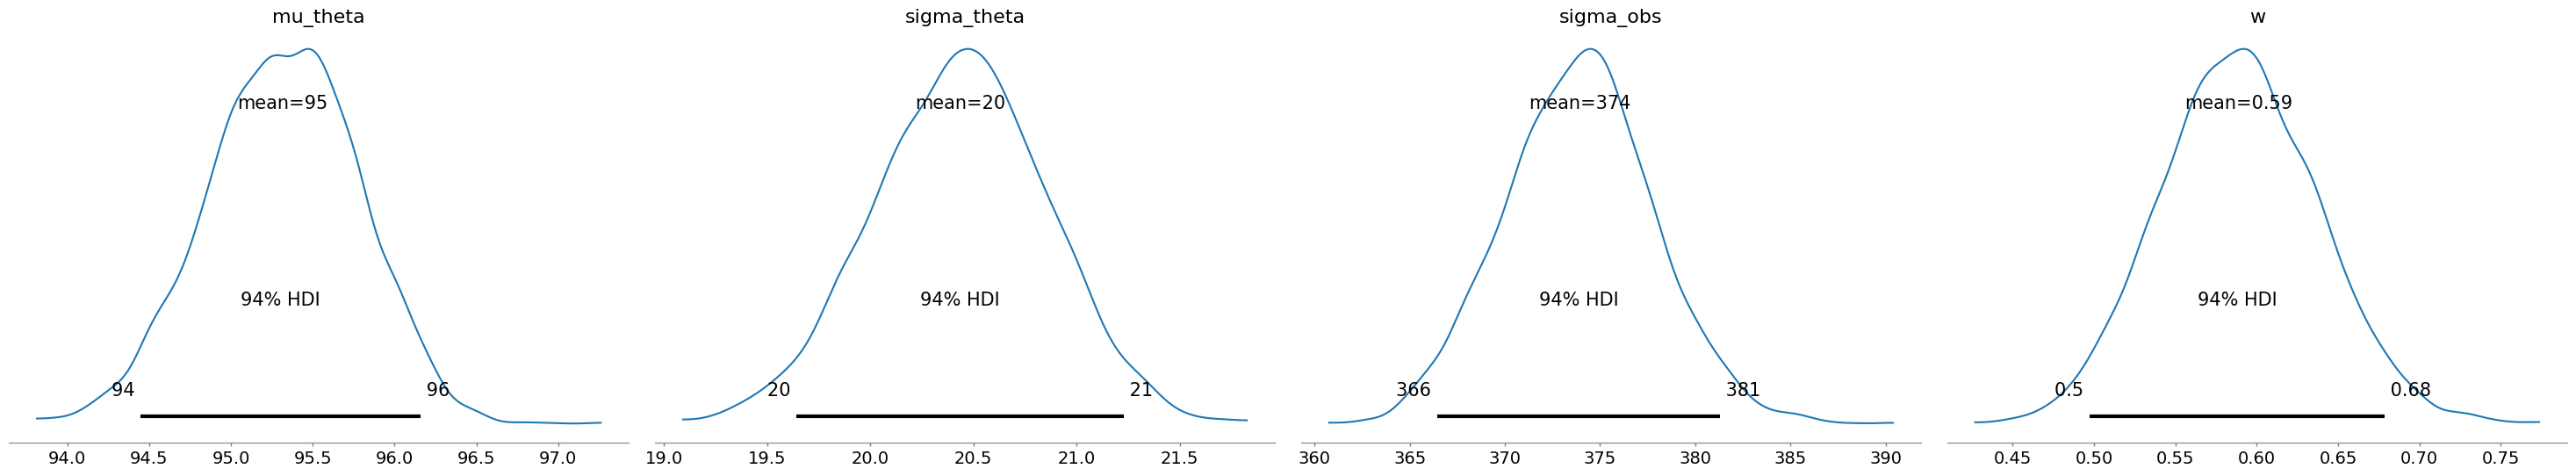

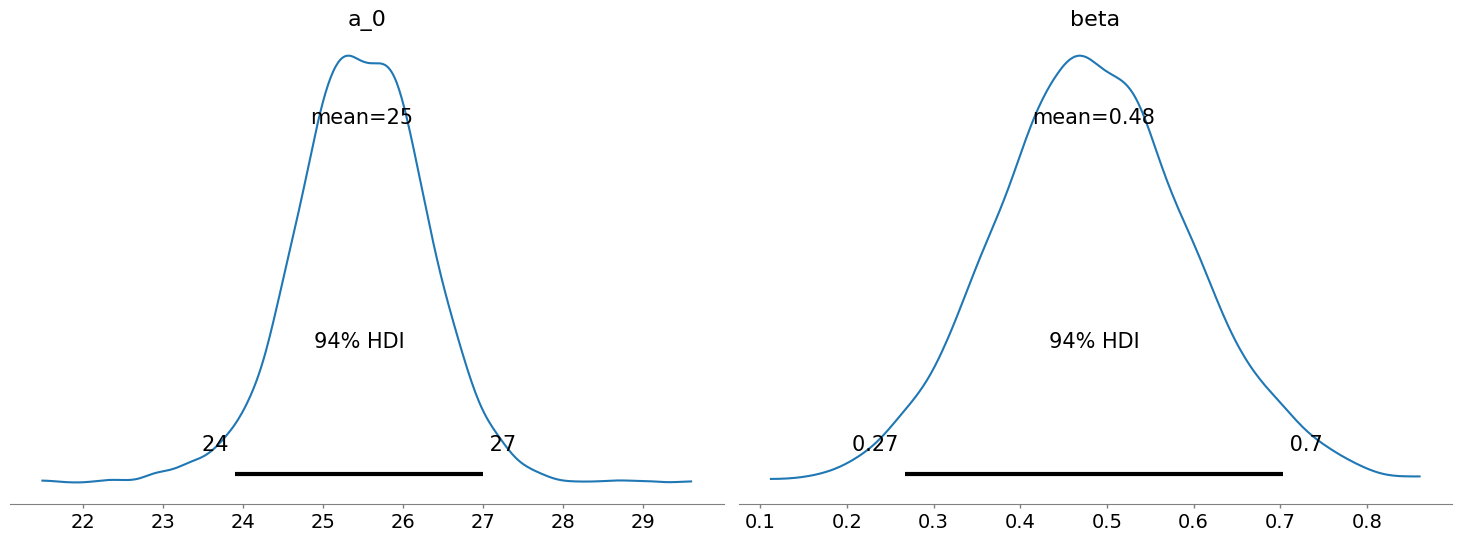

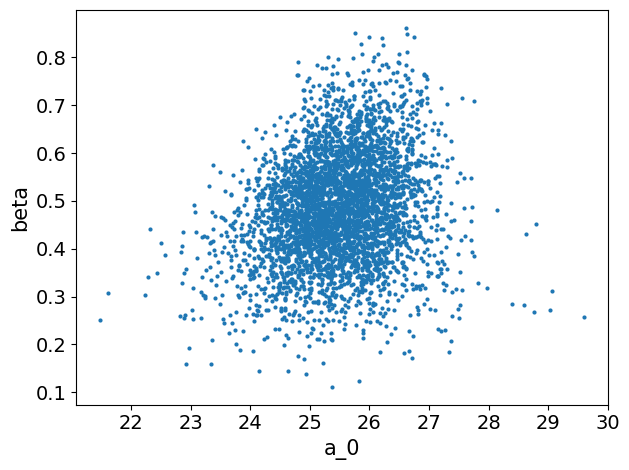

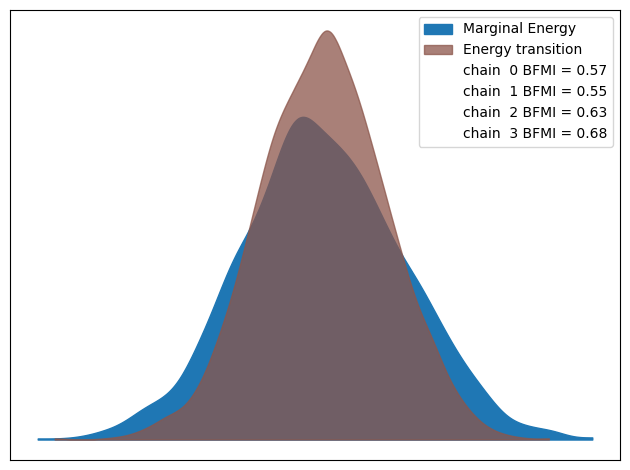

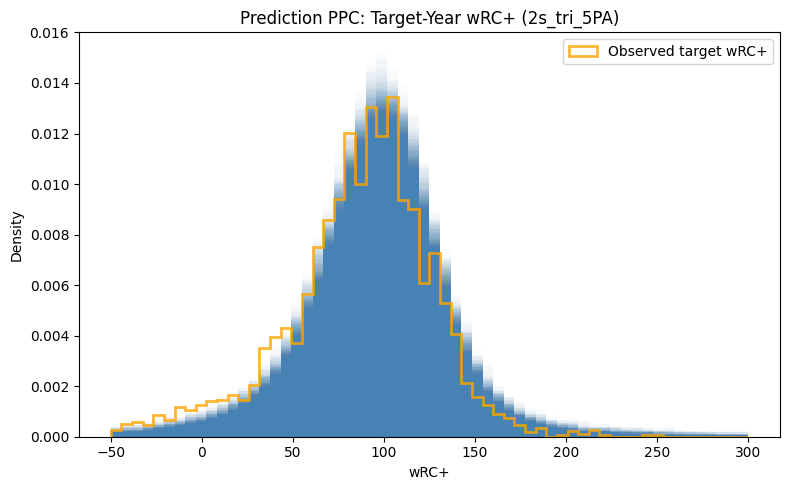

/Users/johannhatzius/Desktop/GitHub/personal/classes/LSE/ST451-Bayesian_ML/project/notebooks/models/block3/../../../src/models/marcel.py:913: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_vals = az.hdi(age_effects.T, hdi_prob=0.94)  # (n_ages, 2)


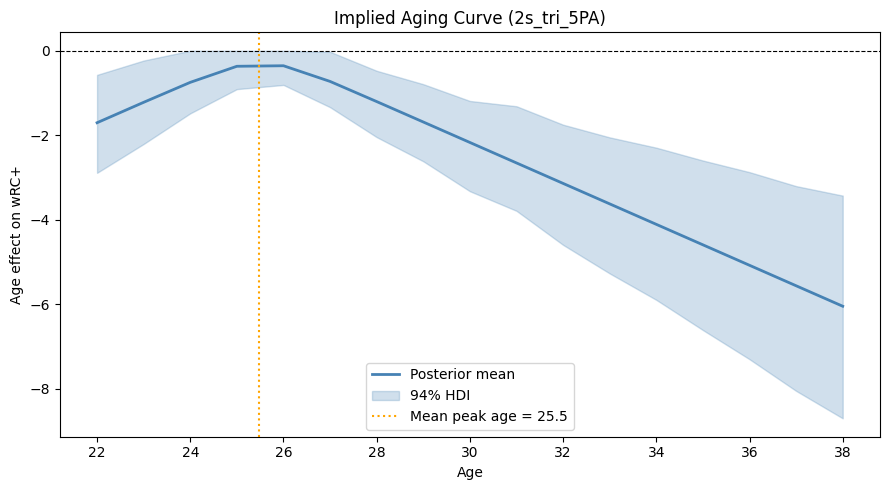

In [9]:
results = run_marcel_diagnostics(
    trace,
    pred_df,
    n_seasons=N_SEASONS,
    aging_form=AGING_FORM,
    run_tag=RUN_TAG,
    block2_summary=block2_ref,
    output_dir=".",
)

## 5. Save trace

In [10]:
with open(TRACE_FILE, 'wb') as f:
    pickle.dump(trace, f)
print(f"Trace saved to notebooks/models/block3/{TRACE_FILE}")

Trace saved to notebooks/models/block3/trace_2s_tri_5PA.pkl


## 6. Inspect a single player-season projection

Fill in `player_name` and `season` to see the age-adjusted posterior predictive
distribution for that player vs. the observed result.

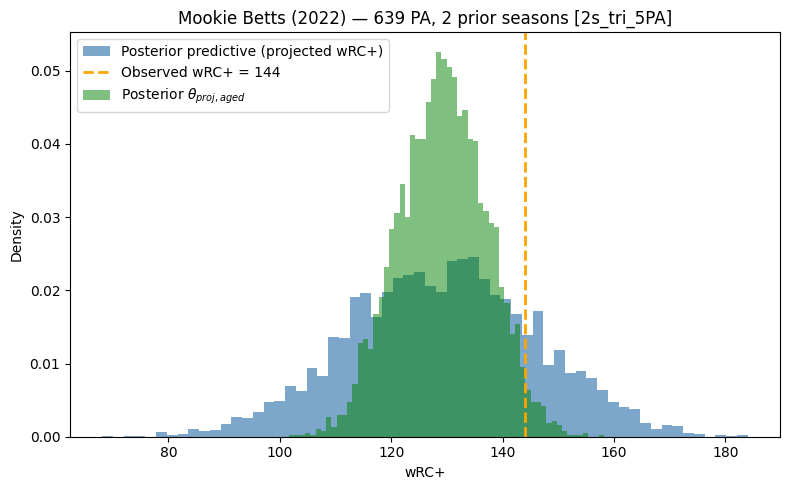

In [11]:
# ---- Fill these in ----
player_name = "Mookie Betts"
season      = 2022   # must be in the prediction window (2018–2023 for two-season;
                     # 2019–2023 for three-season)
# ------------------------

matches = pred_df[pred_df["Name"] == player_name]
if matches.empty:
    raise ValueError(f"No player named '{player_name}' found in prediction table")
unique_ids = matches["IDfg"].unique()
if len(unique_ids) > 1:
    raise ValueError(
        f"'{player_name}' maps to multiple player IDs: {unique_ids.tolist()}. "
        "Use IDfg directly to disambiguate."
    )

row = matches[matches["Season"] == season]
if row.empty:
    available = sorted(matches["Season"].unique())
    raise ValueError(f"'{player_name}' has no projection for {season}. Available: {available}")

key     = row["pred_key"].values[0]
obs_wrc = row["wRC+"].values[0]
obs_pa  = row["PA"].values[0]
n_prior = row["n_prior"].values[0]

ppc_draws        = trace.posterior_predictive["wrc_pred"].sel(pred_row=key).values.flatten()
theta_proj_draws = trace.posterior["theta_proj_aged"].sel(pred_row=key).values.flatten()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ppc_draws, bins=60, density=True, alpha=0.7, color="steelblue",
        label="Posterior predictive (projected wRC+)")
ax.axvline(obs_wrc, color="orange", linewidth=2, linestyle="--",
           label=f"Observed wRC+ = {obs_wrc:.0f}")
ax.hist(theta_proj_draws, bins=60, density=True, alpha=0.5, color="green",
        label=r"Posterior $\theta_{proj,aged}$")
ax.set_xlabel("wRC+")
ax.set_ylabel("Density")
ax.set_title(f"{player_name} ({season}) — {obs_pa} PA, {n_prior} prior seasons [{RUN_TAG}]")
ax.legend()
plt.tight_layout()
plt.show()